## Analyzing Historical Stock/Revenue Data and Building a Dashboard

In [62]:
import yfinance as yf
import pandas as pd

In [63]:
# Extract Tesla stock data
tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")

# Reset the index and display first 5 rows
tesla_data.reset_index(inplace=True)
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


<Axes: xlabel='Date'>

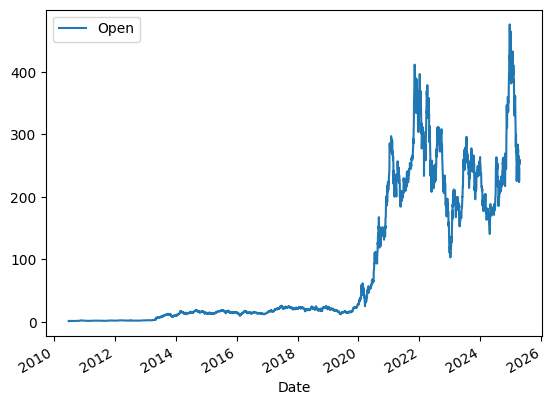

In [64]:
tesla_data.plot(x="Date", y="Open")

## Question 2

In [65]:
!pip install pandas
!pip install requests
!pip install bs4
!pip install html5lib 
!pip install lxml
!pip install plotly

import pandas as pd
import requests
from bs4 import BeautifulSoup

In [66]:
url = "https://finance.yahoo.com/quote/TSLA/history/"

In [67]:
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

In [68]:
Tesla_data2 = pd.DataFrame(columns=["Date", "Open", "High", "Low", "Close", "Volume"])

In [69]:

for row in soup.find("tbody").find_all('tr'):
    col = row.find_all("td")
    date = col[0].text
    Open = col[1].text
    high = col[2].text
    low = col[3].text
    close = col[4].text
    adj_close = col[5].text
    volume = col[6].text
    Tesla_data2 = pd.concat([Tesla_data2,pd.DataFrame({"Date":[date], "Open":[Open], "High":[high], "Low":[low], "Close":[close], "Adj Close":[adj_close], "Volume":[volume]})], ignore_index=True)    

In [70]:
Tesla_data2.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,"Apr 14, 2025",258.33,261.80,253.30,255.34,"12,583,584",255.34
1,"Apr 11, 2025",251.84,257.74,241.36,252.31,"128,656,900",252.31
2,"Apr 10, 2025",260.00,262.49,239.33,252.40,"181,722,600",252.40
3,"Apr 9, 2025",224.69,274.69,223.88,272.20,"219,433,400",272.20
4,"Apr 8, 2025",245.00,250.44,217.80,221.86,"171,603,500",221.86


## Question 3

                       Date      Open      High       Low     Close    Volume  \
0 2002-02-13 00:00:00-05:00  1.620128  1.693350  1.603296  1.691667  76216000   
1 2002-02-14 00:00:00-05:00  1.712707  1.716074  1.670626  1.683251  11021600   
2 2002-02-15 00:00:00-05:00  1.683250  1.687458  1.658002  1.674834   8389600   
3 2002-02-19 00:00:00-05:00  1.666418  1.666418  1.578047  1.607504   7410400   
4 2002-02-20 00:00:00-05:00  1.615920  1.662210  1.603296  1.662210   6892800   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  


<Axes: xlabel='Date'>

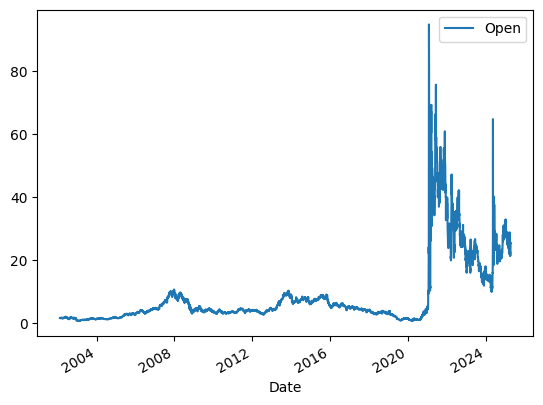

In [71]:
gme = yf.Ticker("GME")
gme_history = gme.history(period="max")
gme_history.reset_index(inplace=True)
print(gme_history.head())
gme_history.plot(x="Date", y="Open")

In [87]:
url= "https://finance.yahoo.com/quote/GME/history/"

In [88]:
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

In [89]:
Gme_data2 = pd.DataFrame(columns=["Date", "Open", "High", "Low", "Close", "Volume"])

In [90]:
for row in soup.find("tbody").find_all('tr'):
    col = row.find_all("td")
    date = col[0].text
    Open = col[1].text
    high = col[2].text
    low = col[3].text
    close = col[4].text
    adj_close = col[5].text
    volume = col[6].text
    Gme_data2 = pd.concat([Gme_data2,pd.DataFrame({"Date":[date], "Open":[Open], "High":[high], "Low":[low], "Close":[close], "Adj Close":[adj_close], "Volume":[volume]})], ignore_index=True)    

In [92]:
Gme_data2.tail()

,Date,Open,High,Low,Close,Volume,Adj Close
246,"Apr 19, 2024",10.20,10.50,10.20,10.42,"2,455,100",10.42
247,"Apr 18, 2024",10.32,10.63,10.27,10.31,"2,175,400",10.31
248,"Apr 17, 2024",10.44,10.59,10.30,10.30,"2,096,700",10.30
249,"Apr 16, 2024",10.00,10.55,9.95,10.37,"4,162,100",10.37
250,"Apr 15, 2024",10.81,10.84,10.06,10.06,"5,086,300",10.06


## Question 5

In [93]:
def make_graph(stock_data, stock, title):
    plt.figure(figsize=(14, 7))
    plt.plot(stock_data['Close'], label=f"{stock} Closing Prices")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Closing Price (USD)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [100]:
import matplotlib.pyplot as plt

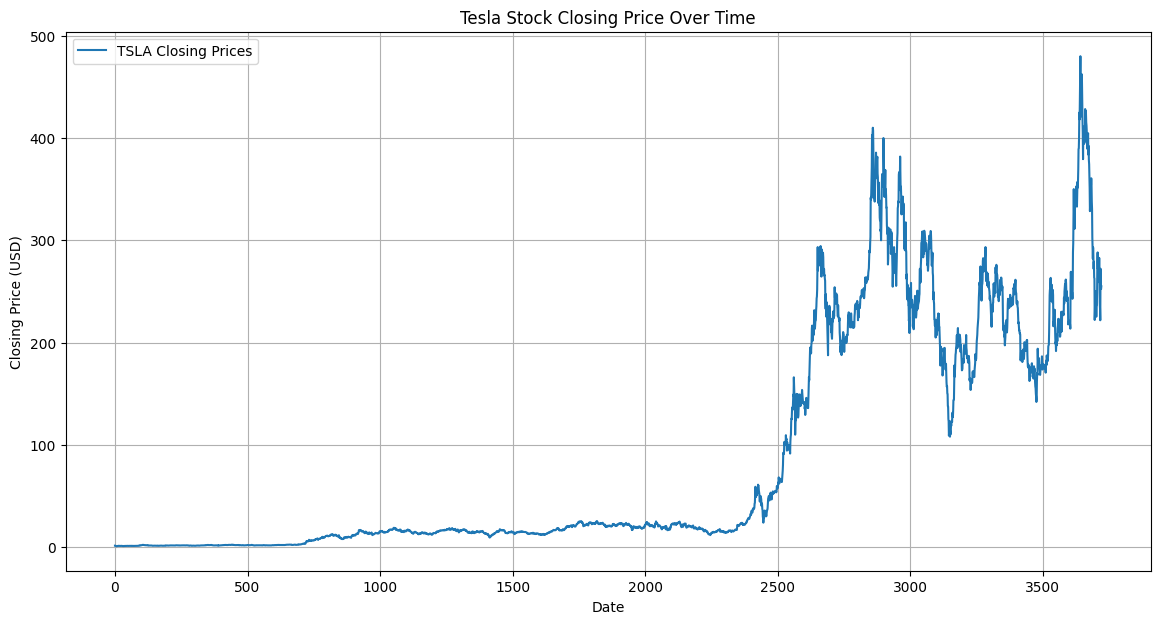

In [101]:
make_graph(tesla_data, "TSLA", "Tesla Stock Closing Price Over Time")

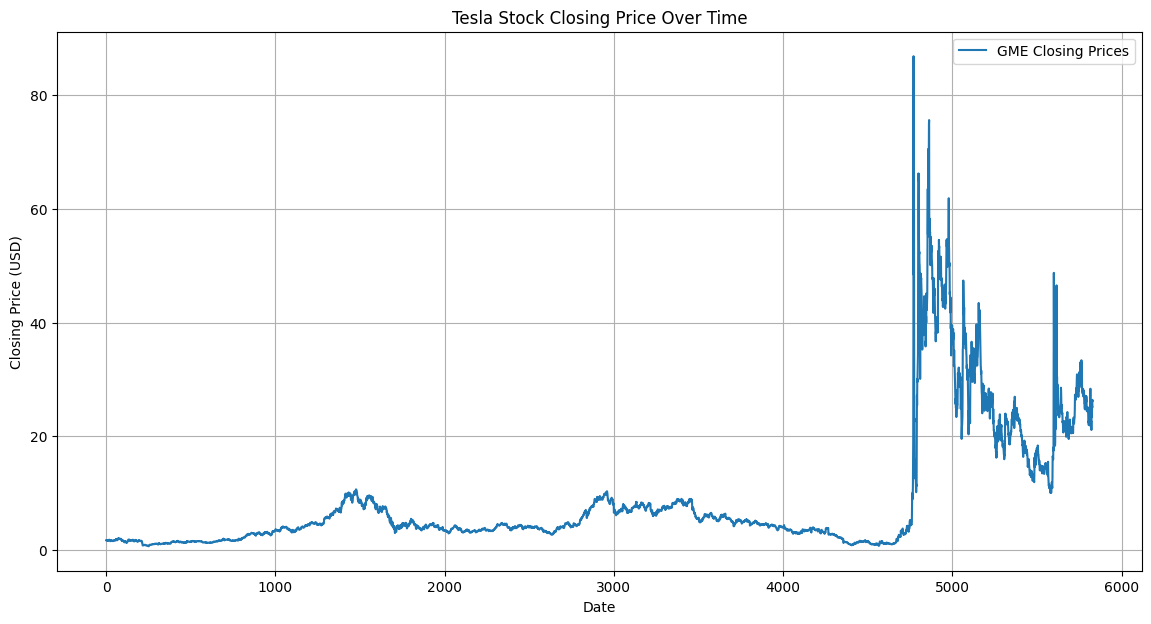

In [102]:
make_graph(gme_history, "GME", "Tesla Stock Closing Price Over Time")